## Рубежный контроль №1
#### Ковалев А.В. ИУ5-63Б
### Загрузка необходимых библиотек

In [240]:
import numpy as np
import pandas as pd
import random
from sklearn.impute import SimpleImputer
from sklearn.impute import MissingIndicator


### Загрузка и первичный анализ данных

In [241]:
df = pd.read_csv('toy_dataset.csv', sep=",")
print('Кол-во строк: ', df.shape[0],'\n' ,'Кол-во столбцов: ', df.shape[1], sep = '')
print(df.dtypes)
print('Пропуски по столбцам:', df.isnull().sum())
df.head(8)

Кол-во строк: 150000
Кол-во столбцов: 6
Number       int64
City        object
Gender      object
Age          int64
Income     float64
Illness     object
dtype: object
Пропуски по столбцам: Number     0
City       0
Gender     0
Age        0
Income     0
Illness    0
dtype: int64


,Number,City,Gender,Age,Income,Illness
0,1,Dallas,Male,41,40367.0,No
1,2,Dallas,Male,54,45084.0,No
2,3,Dallas,Male,42,52483.0,No
3,4,Dallas,Male,40,40941.0,No
4,5,Dallas,Male,46,50289.0,No
5,6,Dallas,Female,36,50786.0,No
6,7,Dallas,Female,32,33155.0,No
7,8,Dallas,Male,39,30914.0,No


#### Пропуски не обнаружены, поэтому создадим их искусственно
### Создание пропусков

In [242]:
for _ in range(15000): 
    df.loc[random.randint(0, len(df) - 1), random.choice(df.columns)] = np.nan

### Повторный анализ данных

In [243]:
print('Кол-во строк: ', df.shape[0],'\n' ,'Кол-во столбцов: ', df.shape[1], sep = '')
print(df.dtypes)
print('Пропуски по столбцам:', df.isnull().sum(), sep="\n")
df.head(8)

Кол-во строк: 150000
Кол-во столбцов: 6
Number     float64
City        object
Gender      object
Age        float64
Income     float64
Illness     object
dtype: object
Пропуски по столбцам:
Number     2511
City       2528
Gender     2438
Age        2463
Income     2474
Illness    2453
dtype: int64


,Number,City,Gender,Age,Income,Illness
0,1.0,Dallas,Male,41.0,40367.0,No
1,2.0,Dallas,Male,54.0,45084.0,No
2,3.0,Dallas,Male,42.0,52483.0,No
3,4.0,Dallas,Male,40.0,40941.0,No
4,5.0,Dallas,Male,46.0,50289.0,No
5,6.0,Dallas,Female,36.0,50786.0,No
6,7.0,Dallas,Female,32.0,33155.0,No
7,8.0,Dallas,Male,39.0,30914.0,No


### Проведем обработку пропусков в колонке City. Предположим, что данный фактор является для нас ключевым. Следовательно строки с пропуском в данной колонке не являются для нас полезными. Значит их можно удалить.

In [244]:
df.dropna(subset = ['City'])

,Number,City,Gender,Age,Income,Illness
0,1.0,Dallas,Male,41.0,40367.0,No
1,2.0,Dallas,Male,54.0,45084.0,No
2,3.0,Dallas,Male,42.0,52483.0,No
3,4.0,Dallas,Male,40.0,40941.0,No
4,5.0,Dallas,Male,46.0,50289.0,No
...,...,...,...,...,...,...
149994,149995.0,Austin,Female,37.0,106097.0,No
149996,149997.0,Austin,Male,25.0,96748.0,No
149997,149998.0,Austin,Male,26.0,111885.0,No
149998,149999.0,Austin,Male,25.0,111878.0,No


### Теперь заполним пропуски в Income средним значением по City

In [245]:
imputer = SimpleImputer(strategy = 'mean')
indicator = MissingIndicator()
df_initial_segments = [df[df['City'] == city] for city in df["City"].unique()]
df_segments = list()
for df_segment in df_initial_segments:
    if df_segment.shape[0]>0:
        df_segments.append(df_segment)
for i in range(len(df_segments)):
    fix_col = df_segments[i].loc[:,['Income']]
    mask_missing = indicator.fit_transform(fix_col)
    fix_col = imputer.fit_transform(fix_col)
    filled_df = fix_col[mask_missing]
    df_segments[i].loc[:,['Income']] = fix_col
df_1 = pd.concat(df_segments, axis=0)
print('Пропуски по столбцам:', df_1.isnull().sum(), sep="\n")

Пропуски по столбцам:
Number     2475
City          0
Gender     2399
Age        2429
Income        0
Illness    2425
dtype: int64


#### И пропуски в Age также заполним средним значением, но на этот раз по датасету.

In [246]:
imputer = SimpleImputer(strategy = 'mean')
indicator = MissingIndicator()
fix_col = df_1.loc[:,['Age']]
mask_missing = indicator.fit_transform(fix_col)
fix_col = imputer.fit_transform(fix_col)
filled_df = fix_col[mask_missing]
df_1.loc[:,['Age']] = fix_col
print('Пропуски по столбцам:', df_1.isnull().sum(), sep="\n")

Пропуски по столбцам:
Number     2475
City          0
Gender     2399
Age           0
Income        0
Illness    2425
dtype: int64


#### Ilness и Gender заполним случайным образом с сохранением пропорции

In [247]:
from random import shuffle
gender_counts = df['Gender'].value_counts()
num_male = gender_counts["Male"]
num_female = gender_counts["Female"]

gender_skip_num = df_1['Gender'].isnull().sum()
male_female_arr = (["Male"] * round(gender_skip_num * num_male/(num_male+num_female ) + 1) 
                   + ["Female"] * round(gender_skip_num * num_male/(num_male+num_female ) + 1)) 
shuffle(male_female_arr)
    
def random_age_imputer(row):
    if row["Gender"] not in["Male", "Female"]:
        row["Gender"] = male_female_arr.pop()
    return row

df_1=df_1.apply(random_age_imputer, axis=1)

print('Пропуски по столбцам:', df_1.isnull().sum(), sep="\n")

Пропуски по столбцам:
Number     2475
City          0
Gender        0
Age           0
Income        0
Illness    2425
dtype: int64


#### Пропуски в столбце Illness заполним наиболее часто встречающимся значением.

In [248]:
imputer = SimpleImputer(strategy = 'most_frequent')
indicator = MissingIndicator()
fix_col = df_1.loc[:,['Illness']]
mask_missing = indicator.fit_transform(fix_col)
fix_col = imputer.fit_transform(fix_col)
filled_df = fix_col[mask_missing]
df_1.loc[:,['Illness']] = fix_col
print('Пропуски по столбцам:', df_1.isnull().sum(), sep="\n")

Пропуски по столбцам:
Number     2475
City          0
Gender        0
Age           0
Income        0
Illness       0
dtype: int64


#### Предположим, что Number не имеет заметного значения и исключим его. 

In [249]:
df_1 = df_1.drop(["Number"], axis=1)
print('Пропуски по столбцам:', df_1.isnull().sum(), sep="\n")

Пропуски по столбцам:
City       0
Gender     0
Age        0
Income     0
Illness    0
dtype: int64


#### Ящик с усами для Age

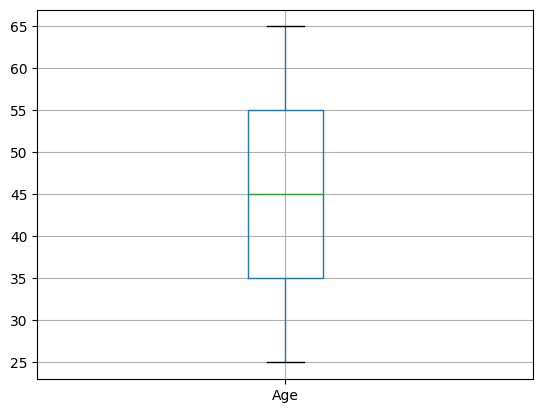

In [250]:
boxplot = df_1.boxplot(column=['Age']) 

#### Выводы
1. Использовал импьютацию (среднего, случайного значения с сохранением пропорции, наиболее частого значения), удаление строки и столбца.
2. В дальнейшем я бы обучил модель, предсказывающую Illnes на основе остальных параметров.